In [2]:
import kagglehub
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Path to dataset files:", path)

c:\Users\Fazeel\Desktop\ziriz\LSTM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 13.9M/13.9M [00:05<00:00, 2.75MB/s]

Extracting files...


Path to dataset files: C:\Users\Fazeel\.cache\kagglehub\datasets\hassan06\nslkdd\versions\1


## CELL 1: IMPORTS & DATA LOADING

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
import os
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Column names for NSL-KDD
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Load data - ADJUST PATH TO YOUR DATASET LOCATION
dataset_path = r'C:\Users\Fazeel\Desktop\ziriz\LSTM\hassan06\nslkdd\versions\1\nsl-kdd'  # Change this to your path

train_file = 'KDDTrain+.txt'
test_file = 'KDDTest+.txt'

train_df = pd.read_csv(f'{dataset_path}/{train_file}', names=column_names, header=None)
test_df = pd.read_csv(f'{dataset_path}/{test_file}', names=column_names, header=None)

print(f"   Training set: {train_df.shape}")
print(f"   Test set: {test_df.shape}")

# Create binary labels
train_df['binary_label'] = train_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'anomaly')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'anomaly')

print(f"\n Class Distribution:")
print(f"   Training - Normal: {(train_df['binary_label']=='normal').sum():,}, Anomaly: {(train_df['binary_label']=='anomaly').sum():,}")
print(f"   Test - Normal: {(test_df['binary_label']=='normal').sum():,}, Anomaly: {(test_df['binary_label']=='anomaly').sum():,}")

   Training set: (125973, 43)
   Test set: (22544, 43)

 Class Distribution:
   Training - Normal: 67,343, Anomaly: 58,630
   Test - Normal: 9,711, Anomaly: 12,833


## CELL 2: FEATURE SELECTION & PREPROCESSING

In [28]:
selected_features = [
    # Temporal features
    'count', 'dst_host_srv_count', 'dst_host_diff_srv_rate',
    'srv_count', 'dst_host_count', 'dst_host_same_srv_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    # Error rates
    'serror_rate', 'rerror_rate',
    'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate',
    # Connection features
    'src_bytes', 'dst_bytes', 'duration',
    'dst_host_same_src_port_rate', 'protocol_type', 'flag',
    # Content/Auth features
    'logged_in', 'num_failed_logins', 'num_root', 'hot',
    # Additional features
    'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate'
]

features_with_label = selected_features + ['binary_label']

# Select features
train_selected = train_df[features_with_label].copy()
test_selected = test_df[features_with_label].copy()

print(f"\n Selected {len(selected_features)} features")
print(f"   Training shape: {train_selected.shape}")
print(f"   Test shape: {test_selected.shape}")

# Log transformation for byte and duration features
train_selected['src_bytes'] = np.log1p(train_selected['src_bytes'])
train_selected['dst_bytes'] = np.log1p(train_selected['dst_bytes'])
train_selected['duration'] = np.log1p(train_selected['duration'])

test_selected['src_bytes'] = np.log1p(test_selected['src_bytes'])
test_selected['dst_bytes'] = np.log1p(test_selected['dst_bytes'])
test_selected['duration'] = np.log1p(test_selected['duration'])

# One-hot encode protocol_type
train_selected = pd.get_dummies(train_selected, columns=['protocol_type'], prefix='protocol')
test_selected = pd.get_dummies(test_selected, columns=['protocol_type'], prefix='protocol')

# Label encode flag
le_flag = LabelEncoder()
train_selected['flag'] = le_flag.fit_transform(train_selected['flag'].astype(str))
test_selected['flag'] = le_flag.transform(test_selected['flag'].astype(str))

# Separate normal and anomaly
train_normal = train_selected[train_selected['binary_label'] == 'normal'].copy()
train_normal = train_normal.drop('binary_label', axis=1)

test_labels = test_selected['binary_label'].copy()
test_data = test_selected.drop('binary_label', axis=1)

print(f"   Normal training samples: {len(train_normal):,}")
print(f"   Test samples (mixed): {len(test_data):,}")
print(f"   Final feature count: {train_normal.shape[1]}")

# Min-Max normalization
scaler = MinMaxScaler()
train_normal_scaled = scaler.fit_transform(train_normal)
test_data_scaled = scaler.transform(test_data)

# Save feature names
feature_names = train_normal.columns.tolist()
n_features = len(feature_names)

print(f"   Features: {n_features}")



 Selected 25 features
   Training shape: (125973, 26)
   Test shape: (22544, 26)
   Normal training samples: 67,343
   Test samples (mixed): 22,544
   Final feature count: 27
   Features: 27


## CELL 3: CREATE API-LIKE TEMPORAL SEQUENCES

In [29]:
def create_api_like_sequences(data_scaled, labels_series, feature_names, seq_length=10, verbose=True):
    data_df = pd.DataFrame(data_scaled, columns=feature_names)
    protocol_cols = [col for col in data_df.columns if 'protocol_' in col]
    if verbose:
        print(f"\n Input data:")
        print(f"   Samples: {len(data_df):,}")
        print(f"   Features: {len(feature_names)}")
        print(f"   Protocol columns: {protocol_cols}")

    data_df['api_session'] = (
        data_df['srv_count'].round(1).astype(str) + '_' +
        data_df['same_srv_rate'].round(2).astype(str) + '_' +
        data_df[protocol_cols].idxmax(axis=1)  # Dominant protocol
    )

    data_df['request_order'] = (
        data_df['count'] * 0.6 +           # Request frequency (primary)
        data_df['dst_bytes'] * 0.4          # Data volume (secondary)
    )

    data_df['label'] = labels_series.values
    data_df_sorted = data_df.sort_values(['api_session', 'request_order'])
    session_sizes = data_df.groupby('api_session').size()

    if verbose:
        print(f"   Unique sessions: {data_df['api_session'].nunique():,}")
        print(f"   Avg connections/session: {session_sizes.mean():.1f}")
        print(f"   Median connections/session: {session_sizes.median():.0f}")
        print(f"   Max connections in session: {session_sizes.max():,}")
        print(f"   Sessions with {seq_length} connections: {(session_sizes >= seq_length).sum():,}")

    sequences = []
    sequence_labels = []
    label_stats = {
        'pure_normal': 0,
        'pure_anomaly': 0,
        'mixed': 0,
        'mixed_normal_labeled': 0,
        'mixed_anomaly_labeled': 0
    }
    session_groups = data_df_sorted.groupby('api_session')
    
    if verbose:
        print("")

    for session_id, group in session_groups:
        if len(group) >= seq_length:
            # Create overlapping sequences (sliding window)
            for i in range(len(group) - seq_length + 1):
                # Extract sequence features
                seq = group.iloc[i:i+seq_length][feature_names].values
                sequences.append(seq)

                #  MAJORITY VOTE LABELING
                seq_labels = group.iloc[i:i+seq_length]['label'].values

                # Count occurrences
                normal_count = (seq_labels == 'normal').sum()
                anomaly_count = (seq_labels == 'anomaly').sum()

                # Track purity statistics
                if normal_count == seq_length:
                    label_stats['pure_normal'] += 1
                    final_label = 'normal'
                elif anomaly_count == seq_length:
                    label_stats['pure_anomaly'] += 1
                    final_label = 'anomaly'
                else:
                    label_stats['mixed'] += 1
                    # Majority vote
                    if anomaly_count > normal_count:
                        final_label = 'anomaly'
                        label_stats['mixed_anomaly_labeled'] += 1
                    elif normal_count > anomaly_count:
                        final_label = 'normal'
                        label_stats['mixed_normal_labeled'] += 1
                    else:
                        # Tie-breaker: use middle timestep
                        final_label = group.iloc[i+5]['label']
                        if final_label == 'anomaly':
                            label_stats['mixed_anomaly_labeled'] += 1
                        else:
                            label_stats['mixed_normal_labeled'] += 1

                sequence_labels.append(final_label)

    # Convert to numpy arrays
    sequences = np.array(sequences)
    sequence_labels = np.array(sequence_labels)

    if verbose:
        print(f"\n Sequences created: {len(sequences):,}")
        print(f"   Shape: {sequences.shape} (samples, timesteps, features)")

        # Sequence composition statistics
        print(f"\n Sequence label composition:")
        print(f"   Pure normal (10/10 normal): {label_stats['pure_normal']:,} ({label_stats['pure_normal']/len(sequences)*100:.1f}%)")
        print(f"   Pure anomaly (10/10 anomaly): {label_stats['pure_anomaly']:,} ({label_stats['pure_anomaly']/len(sequences)*100:.1f}%)")
        print(f"   Mixed sequences: {label_stats['mixed']:,} ({label_stats['mixed']/len(sequences)*100:.1f}%)")

        if label_stats['mixed'] > 0:
            print(f"\n Mixed sequence labeling (majority vote):")
            print(f"   Mixed  Normal: {label_stats['mixed_normal_labeled']:,}")
            print(f"   Mixed  Anomaly: {label_stats['mixed_anomaly_labeled']:,}")

        # Final label distribution
        normal_seq_count = (sequence_labels == 'normal').sum()
        anomaly_seq_count = (sequence_labels == 'anomaly').sum()

        print(f"\n Final sequence labels:")
        print(f"   Normal: {normal_seq_count:,} ({normal_seq_count/len(sequence_labels)*100:.1f}%)")
        print(f"   Anomaly: {anomaly_seq_count:,} ({anomaly_seq_count/len(sequence_labels)*100:.1f}%)")

    # Step 7: Verify temporal structure
    sample_size = min(1000, len(sequences))
    within_seq_diff = []
    between_seq_diff = []

    np.random.seed(42)  # Reproducibility
    for i in range(sample_size):
        seq = sequences[i]
        # Within-sequence: consecutive timestep differences
        for t in range(len(seq) - 1):
            diff = np.abs(seq[t+1] - seq[t]).mean()
            within_seq_diff.append(diff)

        # Between-sequence: random pair differences
        idx1, idx2 = np.random.randint(0, len(sequences), 2)
        diff = np.abs(sequences[idx1][0] - sequences[idx2][0]).mean()
        between_seq_diff.append(diff)

    within_mean = np.mean(within_seq_diff)
    between_mean = np.mean(between_seq_diff)
    ratio = within_mean / between_mean

    if verbose:
        print(f"\n Temporal structure verification:")
        print(f"   Within-sequence difference: {within_mean:.6f}")
        print(f"   Between-sequence difference: {between_mean:.6f}")
        print(f"   Temporal ratio: {ratio:.2f}")

        if ratio < 0.5:
            print(f"    EXCELLENT temporal structure! (ratio < 0.5)")
        elif ratio < 0.7:
            print(f"    STRONG temporal structure (ratio < 0.7)")
        elif ratio < 0.9:
            print(f"    GOOD temporal structure (ratio < 0.9)")
        else:
            print(f"     Weak temporal structure (ratio  1.0)")

    return sequences, sequence_labels



print("\nTRAINING DATA: NORMAL SEQUENCES ONLY")


train_sequences, train_seq_labels = create_api_like_sequences(
    train_normal_scaled,
    pd.Series(['normal'] * len(train_normal_scaled)),
    feature_names,
    seq_length=10,
    verbose=True
)

# Verify all training sequences are normal
assert (train_seq_labels == 'normal').all(), " ERROR: Anomalies found in training data!"

print(f"\n VERIFIED: All {len(train_sequences):,} training sequences are NORMAL")

# Split training data into train and validation (80-20)
X_train, X_val = train_test_split(
    train_sequences,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\n Training data split:")
print(f"   X_train: {X_train.shape} (for model training)")
print(f"   X_val: {X_val.shape} (for threshold calculation)")

# Calculate memory usage
train_memory_mb = X_train.nbytes / (1024**2)
val_memory_mb = X_val.nbytes / (1024**2)

print(f"\n Memory usage:")
print(f"   Training data: {train_memory_mb:.2f} MB")
print(f"   Validation data: {val_memory_mb:.2f} MB")
print(f"   Total: {train_memory_mb + val_memory_mb:.2f} MB")

# CREATE TEST SEQUENCES (MIXED)


print("\nTEST DATA: MIXED NORMAL + ANOMALY SEQUENCES")


test_sequences, test_labels_seq = create_api_like_sequences(
    test_data_scaled,
    test_labels,
    feature_names,
    seq_length=10,
    verbose=True
)

print(f"\n Test data created:")
print(f"   Total sequences: {test_sequences.shape[0]:,}")
print(f"   Shape: {test_sequences.shape}")
print(f"   Normal: {(test_labels_seq == 'normal').sum():,}")
print(f"   Anomaly: {(test_labels_seq == 'anomaly').sum():,}")

test_memory_mb = test_sequences.nbytes / (1024**2)
print(f"   Memory: {test_memory_mb:.2f} MB")

# FINAL DATA SUMMARY


print(f"\n Training data (NORMAL only):")
print(f"   X_train: {X_train.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   All labels: 'normal'")

print(f"\n Test data (MIXED):")
print(f"   X_test: {test_sequences.shape}")
print(f"   y_test Normal: {(test_labels_seq=='normal').sum():,} ({(test_labels_seq=='normal').sum()/len(test_labels_seq)*100:.1f}%)")
print(f"   y_test Anomaly: {(test_labels_seq=='anomaly').sum():,} ({(test_labels_seq=='anomaly').sum()/len(test_labels_seq)*100:.1f}%)")

print(f"\n Data characteristics:")
print(f"   Sequence length: 10 timesteps")
print(f"   Features per timestep: {n_features}")
print(f"   Total parameters per sequence: {10 * n_features}")



TRAINING DATA: NORMAL SEQUENCES ONLY

 Input data:
   Samples: 67,343
   Features: 27
   Protocol columns: ['protocol_icmp', 'protocol_tcp', 'protocol_udp']
   Unique sessions: 178
   Avg connections/session: 378.3
   Median connections/session: 5
   Max connections in session: 47,586
   Sessions with 10 connections: 68


 Sequences created: 66,408
   Shape: (66408, 10, 27) (samples, timesteps, features)

 Sequence label composition:
   Pure normal (10/10 normal): 66,408 (100.0%)
   Pure anomaly (10/10 anomaly): 0 (0.0%)
   Mixed sequences: 0 (0.0%)

 Final sequence labels:
   Normal: 66,408 (100.0%)
   Anomaly: 0 (0.0%)

 Temporal structure verification:
   Within-sequence difference: 0.033260
   Between-sequence difference: 0.131336
   Temporal ratio: 0.25
    EXCELLENT temporal structure! (ratio < 0.5)

 VERIFIED: All 66,408 training sequences are NORMAL

 Training data split:
   X_train: (53126, 10, 27) (for model training)
   X_val: (13282, 10, 27) (for threshold calculation)

 M

## CELL 4: BUILD & TRAIN LSTM AUTOENCODER

In [ ]:
print("="*80)
print("LSTM AUTOENCODER TRAINING")
print("="*80)

# Model parameters
TIMESTEPS = 10
N_FEATURES = n_features
LATENT_DIM = 16

print(f"\n Architecture:")
print(f"   Input: ({TIMESTEPS}, {N_FEATURES})")
print(f"   Encoder: LSTM(64)  LSTM(32)  Latent({LATENT_DIM})")
print(f"   Decoder: LSTM(32)  LSTM(64)  Output({N_FEATURES})")

# Build model
inputs = Input(shape=(TIMESTEPS, N_FEATURES), name='input')

# Encoder
encoded = LSTM(64, activation='tanh', return_sequences=True, name='encoder_lstm1')(inputs)
encoded = Dropout(0.2)(encoded)
encoded = LSTM(32, activation='tanh', return_sequences=False, name='encoder_lstm2')(encoded)

# Decoder
decoded = RepeatVector(TIMESTEPS, name='repeat')(encoded)
decoded = LSTM(32, activation='tanh', return_sequences=True, name='decoder_lstm1')(decoded)
decoded = Dropout(0.2)(decoded)
decoded = LSTM(64, activation='tanh', return_sequences=True, name='decoder_lstm2')(decoded)

# Output
outputs = TimeDistributed(Dense(N_FEATURES), name='output')(decoded)

# Compile
autoencoder = Model(inputs, outputs, name='LSTM_API_Autoencoder')
autoencoder.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

print(f"   Parameters: {autoencoder.count_params():,}")

autoencoder.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_lstm_api_autoencoder.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

# Training configuration
BATCH_SIZE = 128
EPOCHS = 70

print(f"\n Training configuration:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Max epochs: {EPOCHS}")
print(f"   Expected time: 15-20 minutes on T4 GPU")

# Train
print(f"\n{'='*80}")
print("STARTING TRAINING")
print("="*80)

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print(f"   Epochs: {len(history.history['loss'])}")
print(f"   Best val_loss: {min(history.history['val_loss']):.6f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training History')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## CELL 5: EVALUATION & RESULTS

 Validation MSE: 0.003329  0.004158
 Test MSE: 0.032127  0.037339

 Threshold (85th percentile): 0.006166

 Predictions:
   Predicted anomalies: 11,942 / 21,711
   Actual anomalies: 12,477 / 21,711

PERFORMANCE METRICS

 Accuracy: 0.8831 (88.31%)
 Precision: 0.9161
 Recall: 0.8768
 F1-Score: 0.8960
 ROC-AUC: 0.9555
   Normal error: 0.002675
   Anomaly error: 0.053924


              precision    recall  f1-score   support

      Normal     0.8427    0.8915    0.8664      9234
     Anomaly     0.9161    0.8768    0.8960     12477

    accuracy                         0.8831     21711
   macro avg     0.8794    0.8842    0.8812     21711
weighted avg     0.8849    0.8831    0.8834     21711


 Confusion Matrix:
   TN (Correct Normal): 8,232
   FP (NormalAnomaly): 1,002
   FN (AnomalyNormal): 1,537
   TP (Correct Anomaly): 10,940


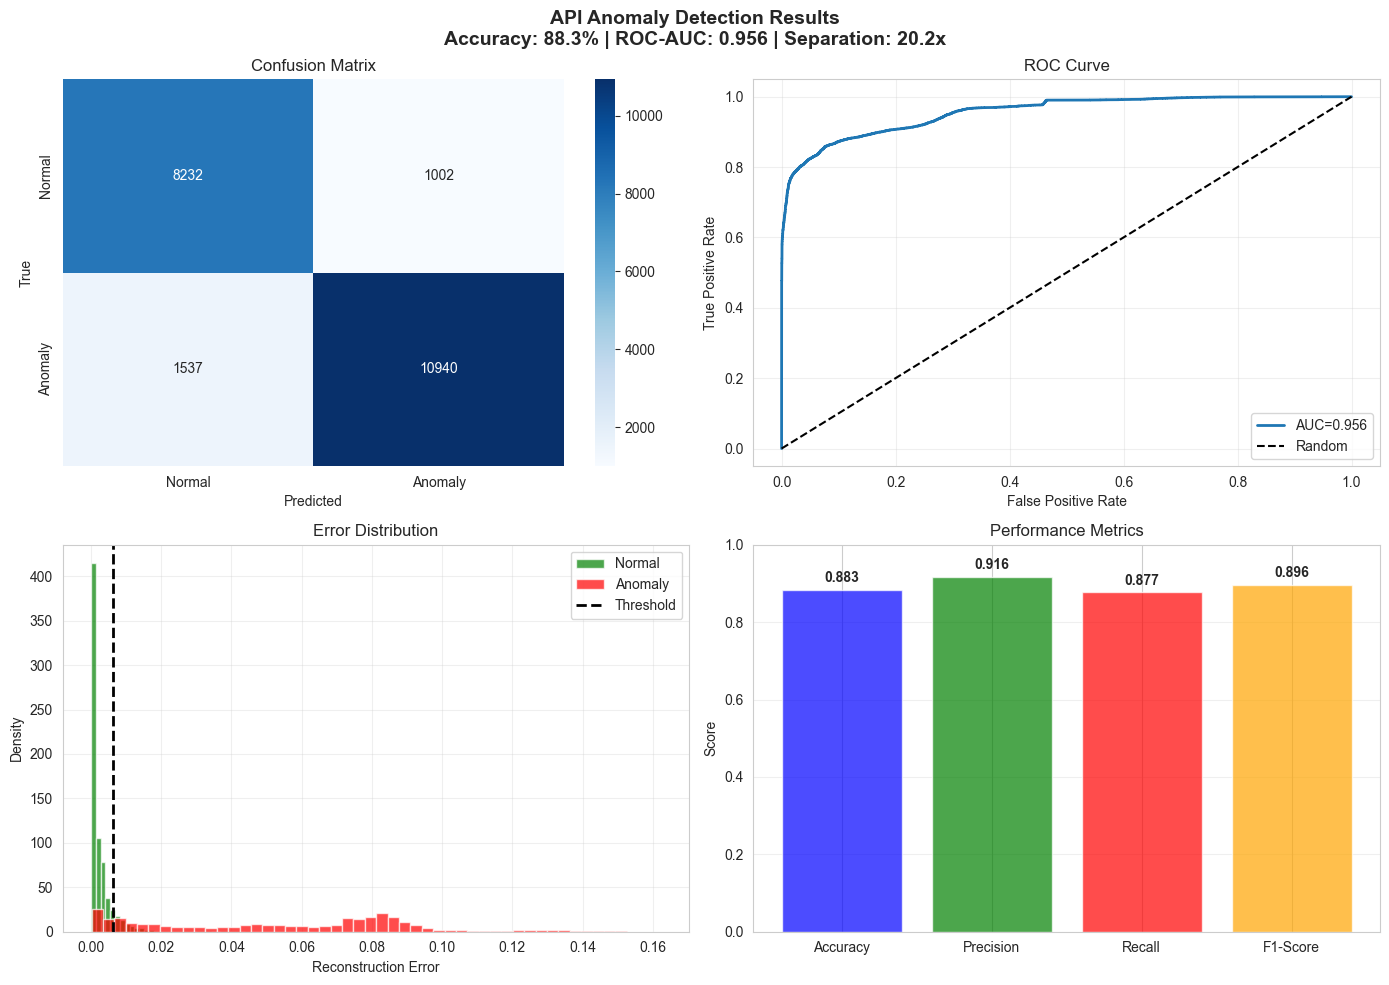

In [19]:


val_pred = autoencoder.predict(X_val, batch_size=256, verbose=0)
val_mse = np.mean(np.power(X_val - val_pred, 2), axis=(1, 2))

test_pred = autoencoder.predict(test_sequences, batch_size=256, verbose=0)
test_mse = np.mean(np.power(test_sequences - test_pred, 2), axis=(1, 2))

print(f" Validation MSE: {val_mse.mean():.6f}  {val_mse.std():.6f}")
print(f" Test MSE: {test_mse.mean():.6f}  {test_mse.std():.6f}")

# Combined threshold
test_normal_idx = (test_labels_seq == 'normal')
test_normal_mse = test_mse[test_normal_idx]
combined_normal_mse = np.concatenate([val_mse, test_normal_mse])

THRESHOLD_PERCENTILE = 85
threshold = np.percentile(combined_normal_mse, THRESHOLD_PERCENTILE)

print(f"\n Threshold ({THRESHOLD_PERCENTILE}th percentile): {threshold:.6f}")

# Make predictions
y_pred = (test_mse > threshold).astype(int)
y_true = (test_labels_seq == 'anomaly').astype(int)

print(f"\n Predictions:")
print(f"   Predicted anomalies: {y_pred.sum():,} / {len(y_pred):,}")
print(f"   Actual anomalies: {y_true.sum():,} / {len(y_true):,}")

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, test_mse)

print("\nPERFORMANCE METRICS")

print(f"\n Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-Score: {f1:.4f}")
print(f" ROC-AUC: {roc_auc:.4f}")

# Separation analysis
normal_error = test_mse[y_true == 0].mean()
anomaly_error = test_mse[y_true == 1].mean()
separation = anomaly_error / normal_error

print(f"   Normal error: {normal_error:.6f}")
print(f"   Anomaly error: {anomaly_error:.6f}")

# Classification report
print(f"\n")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n Confusion Matrix:")
print(f"   TN (Correct Normal): {tn:,}")
print(f"   FP (NormalAnomaly): {fp:,}")
print(f"   FN (AnomalyNormal): {fn:,}")
print(f"   TP (Correct Anomaly): {tp:,}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('True')
axes[0,0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, test_mse)
axes[0,1].plot(fpr, tpr, linewidth=2, label=f'AUC={roc_auc:.3f}')
axes[0,1].plot([0,1], [0,1], 'k--', label='Random')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Error Distribution
axes[1,0].hist(test_mse[y_true==0], bins=50, alpha=0.7, label='Normal', color='green', density=True)
axes[1,0].hist(test_mse[y_true==1], bins=50, alpha=0.7, label='Anomaly', color='red', density=True)
axes[1,0].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold')
axes[1,0].set_xlabel('Reconstruction Error')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Error Distribution')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Metrics Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
axes[1,1].bar(metrics_names, metrics_values, color=['blue', 'green', 'red', 'orange'], alpha=0.7)
axes[1,1].set_ylim([0, 1])
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Performance Metrics')
axes[1,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(metrics_values):
    axes[1,1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle(f'API Anomaly Detection Results\nAccuracy: {accuracy:.1%} | ROC-AUC: {roc_auc:.3f} | Separation: {separation:.1f}x',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## IMPROVED RECONSTRUCTION COMPARISON (SCALED 0-1)

   Normal sequence #18422
      Reconstruction error: 0.001041
   High-error anomaly #4243
      Reconstruction error: 0.162298
   Medium-error anomaly #20274
      Reconstruction error: 0.057566


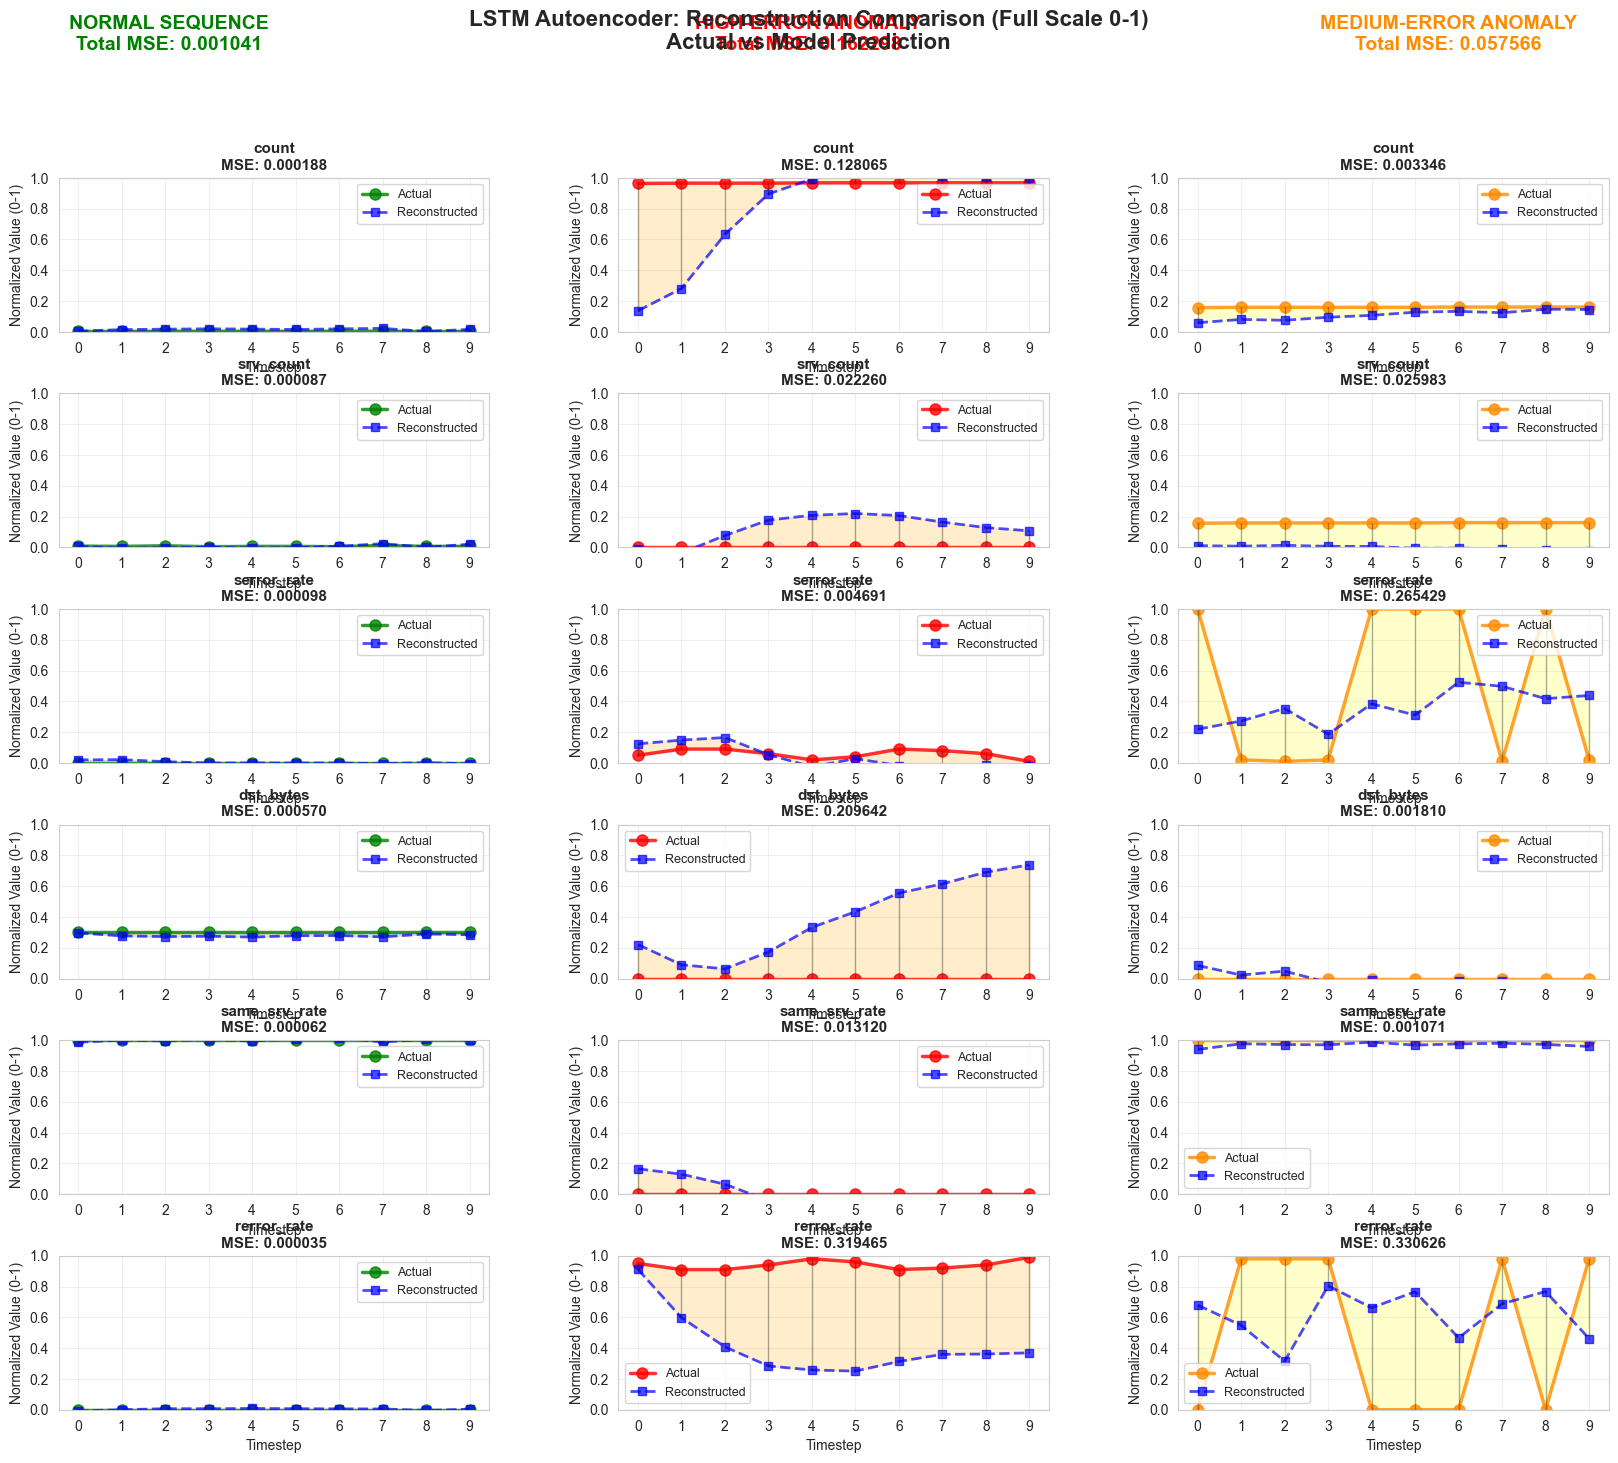

In [21]:
import matplotlib.pyplot as plt
import numpy as np



normal_indices = np.where(test_labels_seq == 'normal')[0]
anomaly_indices = np.where(test_labels_seq == 'anomaly')[0]

# Select one good normal, one anomaly with high error, one with medium error
np.random.seed(42)

# Pick a typical normal sequence
normal_idx = normal_indices[np.random.randint(0, len(normal_indices))]

# Pick anomaly with HIGH reconstruction error
test_pred = autoencoder.predict(test_sequences, batch_size=256, verbose=0)
test_mse = np.mean(np.power(test_sequences - test_pred, 2), axis=(1, 2))
anomaly_mse_values = test_mse[anomaly_indices]
high_error_anomaly_idx = anomaly_indices[np.argmax(anomaly_mse_values)]

# Pick anomaly with MEDIUM reconstruction error (around median)
median_error_idx = np.argsort(anomaly_mse_values)[len(anomaly_mse_values)//2]
medium_error_anomaly_idx = anomaly_indices[median_error_idx]

print(f"   Normal sequence #{normal_idx}")
print(f"      Reconstruction error: {test_mse[normal_idx]:.6f}")
print(f"   High-error anomaly #{high_error_anomaly_idx}")
print(f"      Reconstruction error: {test_mse[high_error_anomaly_idx]:.6f}")
print(f"   Medium-error anomaly #{medium_error_anomaly_idx}")
print(f"      Reconstruction error: {test_mse[medium_error_anomaly_idx]:.6f}")
key_features = {
    'count': feature_names.index('count'),
    'srv_count': feature_names.index('srv_count'),
    'serror_rate': feature_names.index('serror_rate'),
    'dst_bytes': feature_names.index('dst_bytes'),
    'same_srv_rate': feature_names.index('same_srv_rate'),
    'rerror_rate': feature_names.index('rerror_rate'),
}

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(6, 3, hspace=0.4, wspace=0.3)



for idx, (feature_name, feature_idx) in enumerate(key_features.items()):
    ax = fig.add_subplot(gs[idx, 0])
    
    actual = test_sequences[normal_idx][:, feature_idx]
    reconstructed = test_pred[normal_idx][:, feature_idx]
    
    timesteps = np.arange(10)
    ax.plot(timesteps, actual, marker='o', linewidth=2.5, label='Actual', 
            color='green', markersize=8, alpha=0.8)
    ax.plot(timesteps, reconstructed, marker='s', linewidth=2, linestyle='--', 
            label='Reconstructed', color='blue', markersize=6, alpha=0.7)
    
    ax.fill_between(timesteps, actual, reconstructed, alpha=0.2, color='gray')
    
    feature_mse = np.mean((actual - reconstructed)**2)
    
    ax.set_xlabel('Timestep', fontsize=10)
    ax.set_ylabel('Normalized Value (0-1)', fontsize=10)
    ax.set_title(f'{feature_name}\nMSE: {feature_mse:.6f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)
    ax.set_xticks(timesteps)
    
    ax.set_ylim([0, 1])
    
    for t in range(10):
        ax.plot([t, t], [actual[t], reconstructed[t]], 'k-', alpha=0.3, linewidth=1)

fig.text(0.18, 0.96, f'NORMAL SEQUENCE\nTotal MSE: {test_mse[normal_idx]:.6f}', 
         ha='center', fontsize=14, fontweight='bold', color='green')



for idx, (feature_name, feature_idx) in enumerate(key_features.items()):
    ax = fig.add_subplot(gs[idx, 1])
    
    actual = test_sequences[high_error_anomaly_idx][:, feature_idx]
    reconstructed = test_pred[high_error_anomaly_idx][:, feature_idx]
    
    timesteps = np.arange(10)
    ax.plot(timesteps, actual, marker='o', linewidth=2.5, label='Actual', 
            color='red', markersize=8, alpha=0.8)
    ax.plot(timesteps, reconstructed, marker='s', linewidth=2, linestyle='--', 
            label='Reconstructed', color='blue', markersize=6, alpha=0.7)
    
    ax.fill_between(timesteps, actual, reconstructed, alpha=0.2, color='orange')
    
    feature_mse = np.mean((actual - reconstructed)**2)
    
    ax.set_xlabel('Timestep', fontsize=10)
    ax.set_ylabel('Normalized Value (0-1)', fontsize=10)
    ax.set_title(f'{feature_name}\nMSE: {feature_mse:.6f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)
    ax.set_xticks(timesteps)
    
    ax.set_ylim([0, 1])
    
    for t in range(10):
        ax.plot([t, t], [actual[t], reconstructed[t]], 'k-', alpha=0.3, linewidth=1)

fig.text(0.50, 0.96, f'HIGH-ERROR ANOMALY\nTotal MSE: {test_mse[high_error_anomaly_idx]:.6f}', 
         ha='center', fontsize=14, fontweight='bold', color='red')


for idx, (feature_name, feature_idx) in enumerate(key_features.items()):
    ax = fig.add_subplot(gs[idx, 2])
    
    actual = test_sequences[medium_error_anomaly_idx][:, feature_idx]
    reconstructed = test_pred[medium_error_anomaly_idx][:, feature_idx]
    
    timesteps = np.arange(10)
    ax.plot(timesteps, actual, marker='o', linewidth=2.5, label='Actual', 
            color='darkorange', markersize=8, alpha=0.8)
    ax.plot(timesteps, reconstructed, marker='s', linewidth=2, linestyle='--', 
            label='Reconstructed', color='blue', markersize=6, alpha=0.7)
    
    ax.fill_between(timesteps, actual, reconstructed, alpha=0.2, color='yellow')
    
    feature_mse = np.mean((actual - reconstructed)**2)
    
    ax.set_xlabel('Timestep', fontsize=10)
    ax.set_ylabel('Normalized Value (0-1)', fontsize=10)
    ax.set_title(f'{feature_name}\nMSE: {feature_mse:.6f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)
    ax.set_xticks(timesteps)
    
    ax.set_ylim([0, 1])
    
    for t in range(10):
        ax.plot([t, t], [actual[t], reconstructed[t]], 'k-', alpha=0.3, linewidth=1)

fig.text(0.82, 0.96, f'MEDIUM-ERROR ANOMALY\nTotal MSE: {test_mse[medium_error_anomaly_idx]:.6f}', 
         ha='center', fontsize=14, fontweight='bold', color='darkorange')

plt.suptitle('LSTM Autoencoder: Reconstruction Comparison (Full Scale 0-1)\nActual vs Model Prediction', 
             fontsize=16, fontweight='bold', y=0.985)

plt.show()



## Load a trained model

In [ ]:
from tensorflow import keras

MODEL_PATH = r"C:\Users\Fazeel\Desktop\ziriz\LSTM\colab_model\best_lstm_api_autoencoder (1).h5"

def load_keras_model(path):
    try:
        custom_objects = {
            "mse": keras.losses.MeanSquaredError(),
            "mae": keras.losses.MeanAbsoluteError(),
            "mean_squared_error": keras.losses.MeanSquaredError(),
            "mean_absolute_error": keras.losses.MeanAbsoluteError(),
        }
        model = keras.models.load_model(path, custom_objects=custom_objects, safe_mode=False)
        print("Model loaded with custom_objects")
        return model
    except Exception as e1:
        try:
            model = keras.models.load_model(path, compile=False, safe_mode=False)
            print("Model loaded with compile=False")
            return model
        except Exception as e2:
            print("Primary load error:", type(e1).__name__, "-", e1)
            print("Fallback load error:", type(e2).__name__, "-", e2)
            raise

model = load_keras_model(MODEL_PATH)

# Recompile if you loaded with compile=False or want explicit control
model.compile(optimizer="adam",
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.MeanAbsoluteError()])
autoencoder=model
print("Model compiled")



Model loaded with custom_objects
Model compiled
